In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import scipy.stats as stats
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, precision_score, recall_score, f1_score, roc_auc_score

# Linear regression

# Why model was chosen

Linear Regression, Ridge, and Lasso models are applied to this dataset to provide a comprehensive understanding of the relationship between socioeconomic factors and the share of the population with low food access. Linear Regression serves as a baseline model, offering clear interpretability of how variables such as income, poverty, and infrastructure influence the outcome. However, because many of these predictors are likely correlated, this can lead to instability in coefficient estimates. Ridge regression addresses this issue by applying regularization that shrinks coefficients, thereby improving model stability and predictive performance without removing variables. In contrast, Lasso regression performs both regularization and variable selection by shrinking some coefficients to exactly zero, helping identify the most influential predictors in the dataset. Using all three models allows for a balanced approach that combines interpretability, stability, and simplification. This is particularly important in socioeconomic analyses, where variables often overlap in meaning and influence. Comparing these models also helps validate results and ensures robustness in the findings. Ultimately, this approach supports both accurate prediction and meaningful interpretation of the key drivers of low food access.


# Model Assumptions


- Linearity: The relationship between predictors and the response is linear.
- Independence of errors: Observations (counties) are assumed to be independent.
- Homoscedasticity: Variance of residuals is constant across predicted values (checked via residuals vs. fitted plot).
- Normality of errors: Residuals follow a normal distribution (checked via Q-Q plot).
- No multicollinearity: Predictors should not be highly correlated with each other (checked via VIF).

In [2]:
data = pd.read_csv('final_food_system_all.csv')
data = data.drop(columns=['CountyFIPS'])

print(data.head(5))
print(data.shape)

     State          County  Pop2010  county_low_access_10_share  \
0  Alabama  Autauga County    54571                    0.093803   
1  Alabama  Baldwin County   182265                    0.012664   
2  Alabama  Barbour County    27457                    0.169060   
3  Alabama     Bibb County    22915                    0.015935   
4  Alabama   Blount County    57322                    0.000000   

   county_low_income_low_access_10_share  GROCPTH16  SUPERCPTH16  CONVSPTH16  \
0                               0.042257   0.054271     0.018090    0.560802   
1                               0.004639   0.139753     0.033733    0.568650   
2                               0.088892   0.155195     0.038799    0.737177   
3                               0.004459   0.220916     0.044183    0.662749   
4                               0.000000   0.086863     0.017373    0.469059   

   SNAPSPTH17  WICSPTH16  ...  StructuralRisk_norm  FoodSystemFailureScore  \
0    0.804747   0.090511  ...         

In [3]:
data["county_low_access_10_share"].describe()

,county_low_access_10_share
count,3140.000000
mean,0.115115
std,0.190020
min,0.000000
25%,0.004332
50%,0.042444
75%,0.140262
max,1.000000


In [5]:
y = data['county_low_access_10_share']

x = data[['FoodInfrastructureIndex', 'DG_per_10k', 'RetailProxy',
        'NoVehicleRate', 'MedianIncome', 'PovertyRate',
        'UnemploymentRate', 'MedianAge', 'HispanicShare']]

In [6]:
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

# Fitting the model

In [7]:
x_sm = sm.add_constant(x_train)
model_sm = sm.OLS(y_train, x_sm).fit()

print(model_sm.summary())

                                OLS Regression Results                                
Dep. Variable:     county_low_access_10_share   R-squared:                       0.236
Model:                                    OLS   Adj. R-squared:                  0.233
Method:                         Least Squares   F-statistic:                     85.96
Date:                        Wed, 08 Apr 2026   Prob (F-statistic):          1.62e-139
Time:                                14:35:04   Log-Likelihood:                 936.48
No. Observations:                        2512   AIC:                            -1853.
Df Residuals:                            2502   BIC:                            -1795.
Df Model:                                   9                                         
Covariance Type:                    nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------

# Final Model

In [10]:
y1 = data['county_low_access_10_share']

x1 = data[['FoodInfrastructureIndex', 'DG_per_10k', 'RetailProxy',
        'NoVehicleRate', 'MedianIncome', 'PovertyRate',
        'UnemploymentRate', 'MedianAge']]
x1_train, x1_test, y1_train, y1_test = train_test_split(
    x1, y1, test_size=0.2, random_state=42
)

In [29]:
x1_sm = sm.add_constant(x1_train)
model1_sm = sm.OLS(y1_train, x1_sm).fit()

print(model1_sm.summary())

                                OLS Regression Results                                
Dep. Variable:     county_low_access_10_share   R-squared:                       0.236
Model:                                    OLS   Adj. R-squared:                  0.233
Method:                         Least Squares   F-statistic:                     96.56
Date:                        Wed, 08 Apr 2026   Prob (F-statistic):          2.81e-140
Time:                                14:47:37   Log-Likelihood:                 935.91
No. Observations:                        2512   AIC:                            -1854.
Df Residuals:                            2503   BIC:                            -1801.
Df Model:                                   8                                         
Covariance Type:                    nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------

In [30]:
y1_train_pred = model1_sm.predict(x1_sm)
x1_test_sm = sm.add_constant(x1_test)
y1_test_predict = model1_sm.predict(x1_test_sm)
test1_r2 = r2_score(y1_test, y1_test_predict )
print("R² for final model:", test1_r2)

mse1_test = mean_squared_error(y1_test, y1_test_predict)
print("MSE for final model:", mse1_test)

rmse1_test = np.sqrt(mean_squared_error(y1_test, y1_test_predict))
print("RMSE for final model:", rmse1_test)

R² for final model: 0.12999337989164617
MSE for final model: 0.03044556711524623
RMSE for final model: 0.17448658147618754


# Ridge and Lasso

In [41]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler

# Scale features for Ridge (required — regularisation is scale-sensitive)
scaler_lin = StandardScaler()
x1_train_scaled = scaler_lin.fit_transform(x1_train)
x1_test_scaled  = scaler_lin.transform(x1_test)

# Grid search over alpha values
ridge_params = {'alpha': [0.01, 0.1, 1, 10, 50, 100, 200]}
ridge_gs = GridSearchCV(
    Ridge(),
    ridge_params,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1
)
ridge_gs.fit(x1_train_scaled, y1_train)

best_alpha = ridge_gs.best_params_['alpha']
print(f'Best alpha: {best_alpha}')

# Fit final Ridge model with best alpha
ridge_model = Ridge(alpha=best_alpha)
ridge_model.fit(x1_train_scaled, y1_train)
y_ridge_pred = ridge_model.predict(x1_test_scaled)

ridge_r2   = r2_score(y1_test, y_ridge_pred)
ridge_mse  = mean_squared_error(y1_test, y_ridge_pred)
ridge_rmse = np.sqrt(ridge_mse)

print(f'Ridge R²:   {ridge_r2:.4f}')
print(f'Ridge MSE:  {ridge_mse:.6f}')
print(f'Ridge RMSE: {ridge_rmse:.6f}')


Best alpha: 50
Ridge R²:   0.1342
Ridge MSE:  0.030297
Ridge RMSE: 0.174060


In [35]:
from sklearn.linear_model import Lasso
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

# Grid search over alpha values (same idea as Ridge)
lasso_params = {'alpha': [0.0001, 0.001, 0.01, 0.1, 1, 10]}

lasso_gs = GridSearchCV(
    Lasso(max_iter=10000),
    lasso_params,
    cv=10,
    scoring='neg_mean_squared_error',
    n_jobs=-1
)

lasso_gs.fit(x1_train_scaled, y1_train)

best_alpha_lasso = lasso_gs.best_params_['alpha']
print(f'Best Lasso alpha: {best_alpha_lasso}')

# Fit final Lasso model
lasso_model = Lasso(alpha=best_alpha_lasso, max_iter=10000)
lasso_model.fit(x1_train_scaled, y1_train)
y_lasso_pred = lasso_model.predict(x1_test_scaled)

# Metrics
lasso_r2   = r2_score(y1_test, y_lasso_pred)
lasso_mse  = mean_squared_error(y1_test, y_lasso_pred)
lasso_rmse = np.sqrt(lasso_mse)

print(f'Lasso R²:   {lasso_r2:.4f}')
print(f'Lasso MSE:  {lasso_mse:.6f}')
print(f'Lasso RMSE: {lasso_rmse:.6f}')



Best Lasso alpha: 0.0001
Lasso R²:   0.1309
Lasso MSE:  0.030415
Lasso RMSE: 0.174400


In [36]:
print('\n--- Comparison ---')
print(f'OLS Final   R²: {test1_r2:.4f}  RMSE: {rmse1_test:.6f} MSE:{mse1_test:.4f}')
print(f'Ridge       R²: {ridge_r2:.4f}  RMSE: {ridge_rmse:.6f} MSE:{ridge_mse:.4f}')
print(f'Lasso       R²: {lasso_r2:.4f}  RMSE: {lasso_rmse:.6f} MSE:{lasso_mse:.4f}')

# Cross-validation comparison

# Cross-validation score for OLS final model (for fair comparison)
from sklearn.linear_model import LinearRegression as LR
ols_cv = cross_val_score(LR(), x1_train_scaled, y1_train, cv=10, scoring='r2')
ridge_cv = cross_val_score(Ridge(alpha=best_alpha), x1_train_scaled, y1_train, cv=10, scoring='r2')

lasso_cv = cross_val_score(
    Lasso(alpha=best_alpha_lasso, max_iter=10000),
    x1_train_scaled,
    y1_train,
    cv=10,
    scoring='r2'
)

print(f'\n10-Fold CV R² — OLS:   {ols_cv.mean():.4f} (+/- {ols_cv.std():.4f})')
print(f'10-Fold CV R² — Ridge: {ridge_cv.mean():.4f} (+/- {ridge_cv.std():.4f})')
print(f'10-Fold CV R² — Lasso: {lasso_cv.mean():.4f} (+/- {lasso_cv.std():.4f})')


--- Comparison ---
OLS Final   R²: 0.1300  RMSE: 0.174487 MSE:0.0304
Ridge       R²: 0.1342  RMSE: 0.174060 MSE:0.0303
Lasso       R²: 0.1309  RMSE: 0.174400 MSE:0.0304

10-Fold CV R² — OLS:   0.2179 (+/- 0.0840)
10-Fold CV R² — Ridge: 0.2186 (+/- 0.0821)
10-Fold CV R² — Lasso: 0.2179 (+/- 0.0836)


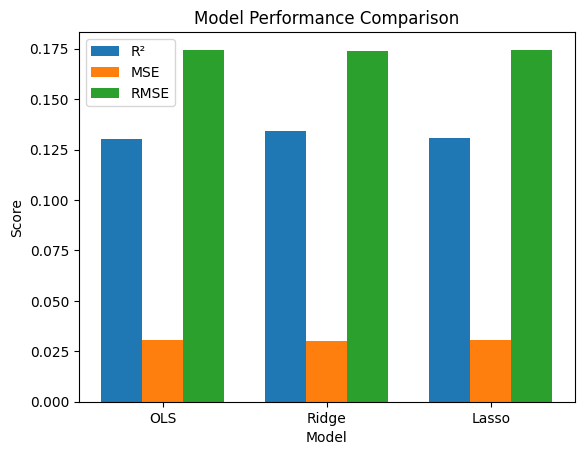

In [38]:
import numpy as np

models = ['OLS', 'Ridge', 'Lasso']

r2_scores = [test1_r2, ridge_r2, lasso_r2]
mse_scores = [mse1_test, ridge_mse, lasso_mse]
rmse_scores = [rmse1_test, ridge_rmse, lasso_rmse]
x = np.arange(len(models))
width = 0.25

plt.figure()

plt.bar(x - width, r2_scores, width, label='R²')
plt.bar(x, mse_scores, width, label='MSE')
plt.bar(x + width, rmse_scores, width, label='RMSE')

plt.xticks(x, models)
plt.title('Model Performance Comparison')
plt.xlabel('Model')
plt.ylabel('Score')
plt.legend()

plt.show()

# Hyperparameter Tuning / Feature Selection

Two models were tested. The **initial model** used 9 predictors: FoodInfrastructureIndex, DG_per_10k, RetailProxy, NoVehicleRate, MedianIncome, PovertyRate, UnemploymentRate, MedianAge, and HispanicShare. The **final model** was refined to 8 predictors by removing HispanicShare, which was statistically insignificant (p-value > 0.05).

Because plain OLS has no regularisation hyperparameters, tuning is performed by:
1. **Feature selection** — removing insignificant predictors (HispanicShare, p > 0.05).
2. **Ridge and Lasso regression** — introduces an `alpha` penalty that shrinks coefficients of correlated features, reducing the train/test R² gap.
3. **Cross-validated alpha search** — GridSearchCV with 5-fold CV selects the best regularisation strength.

# Evaluating Tuned Model - Ridge

In [42]:
coefficients = pd.DataFrame({
    "Feature": x1.columns,
    "Coefficient": ridge_model.coef_
}).sort_values(by="Coefficient", key=abs, ascending=False)

print(coefficients)

                   Feature  Coefficient
0  FoodInfrastructureIndex     0.044964
2              RetailProxy     0.040284
7                MedianAge     0.028102
4             MedianIncome    -0.025790
6         UnemploymentRate    -0.022133
3            NoVehicleRate    -0.020435
5              PovertyRate    -0.019288
1               DG_per_10k    -0.013716


For the variables "MedianIncome, UnemploymentRate, NoVehicleRate, PovertyRate and DG_per_10k" decreases the low access share whereas the FoodInfrastructureIndex, RetailProxy and  MedianAge increases the low access share.


Among the evaluated models, Ridge and Lasso regression outperformed standard linear regression due to their ability to reduce overfitting through regularization. Model comparison based on RMSE, MSE, and R² indicated that Ridge model achieved the lowest RMSE, making it the most reliable in terms of prediction error magnitude.

RMSE was selected as the primary evaluation metric because it provides an interpretable measure of prediction error in the same units as the response variable, making it more meaningful for practical decision-making.

Hyperparameter tuning using cross-validation further improved model generalization by selecting the optimal regularization strength (alpha).

Additionally, the model’s coefficients revealed that FoodInfrastructureIndex, RetailProxy and MedianAge had the strongest influence on the target variable (low access share) at county level, while less important variables were shrunk (Ridge), enhancing model interpretability and reducing complexity.

## Challenges and Solutions

1. Low Model Performance (Low R² ≈ 0.13)

Challenge

The models explain only a small proportion of the variance in the target variable, indicating weak predictive power. This is because of the presence of non-linear relationships not captured by linear models and noise or randomness in the dataset


2. Minimal Performance Difference Between Ridge and Lasso

**Challenge :** Both models produced nearly identical RMSE and MSE values, making it nearly difficult to clearly distinguish the best model.

**Solution:**
Use RMSE as the primary decision metric for consistency and
consider model interpretability as a secondary criterion.




3. Lasso Not Performing Feature Selection

**Challenge :**

Lasso returned an extremely small alpha (0.0001), meaning it did not shrink coefficients to zero or eliminate features.

**Solution:**
Accept that feature selection is not necessary for this dataset and
use Ridge instead for better coefficient stability


4. Model Assumption Limitations

**Challenge:**

Linear models assume:
Linearity
Constant variance (homoscedasticity)
Normally distributed residuals

Residual plots may show violations.

**Solution:**
Validate assumptions using:Residual plots and Residual distribution



5. Hyperparameter Sensitivity

**Challenge:**

Model performance depends on selecting the correct alpha value.

**Solution:**
Use cross-validation (GridSearchCV) to ensure:
Robust parameter selection
Better generalization to unseen data





Despite applying regularization techniques, the relatively low explanatory power of the models suggests that the underlying relationships in the dataset may be weak or non-linear. Ridge regression was ultimately selected due to its slightly superior predictive performance and its ability to handle multicollinearity effectively. Future improvements could involve feature engineering and the exploration of non-linear modeling approaches to better capture complex patterns in the data.



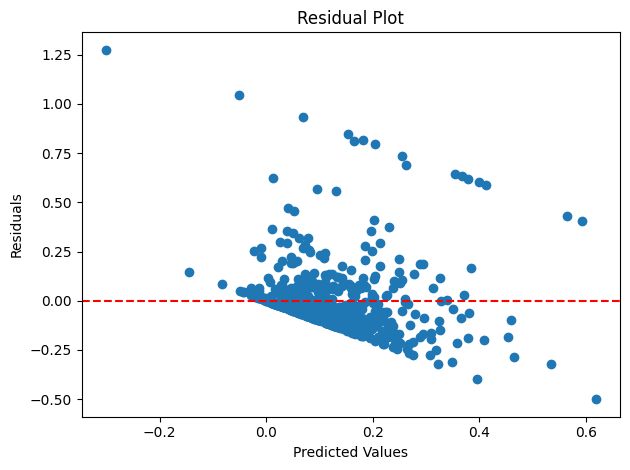

In [45]:
# Residuals for best model
y_pred = ridge_model.predict(x1_test_scaled)
residuals = y_test - y_pred

plt.scatter(y_pred, residuals)
plt.axhline(y=0, color='r', linestyle='--')
plt.title("Residual Plot")
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.tight_layout()
plt.show()

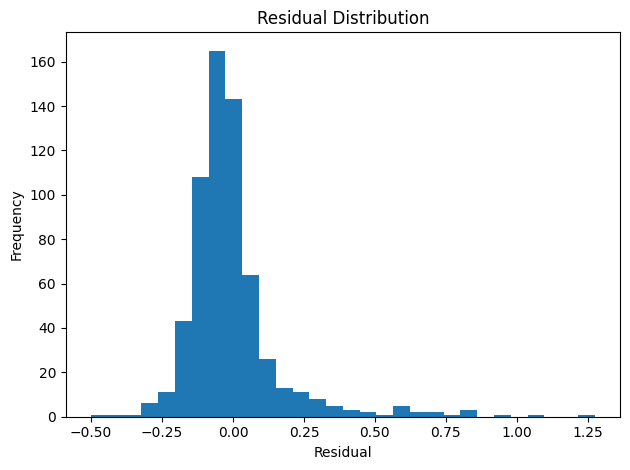

In [46]:
plt.hist(residuals, bins=30)
plt.title("Residual Distribution")
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

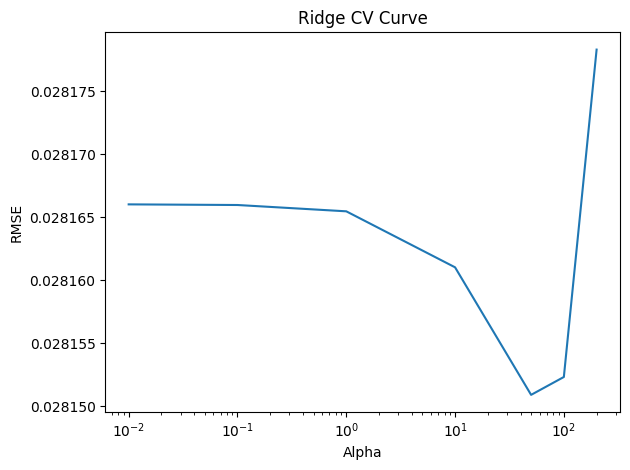

In [47]:
ridge_alphas = ridge_params["alpha"]
ridge_scores = -ridge_gs.cv_results_["mean_test_score"]

plt.plot(ridge_alphas, ridge_scores)
plt.xscale("log")
plt.title("Ridge CV Curve")
plt.xlabel("Alpha")
plt.ylabel("RMSE")
plt.tight_layout()
plt.show()

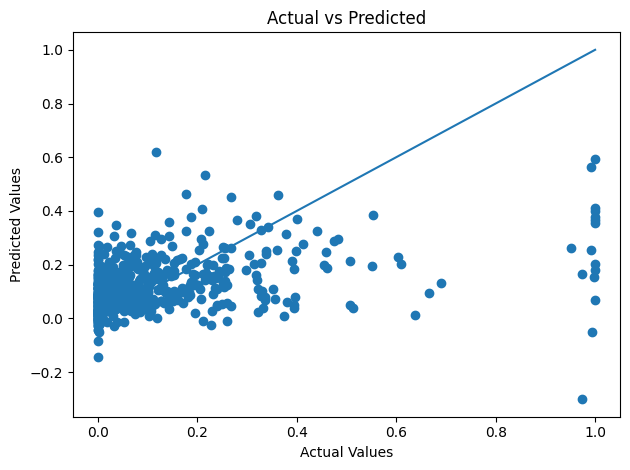

In [48]:
plt.scatter(y_test, y_pred)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()])
plt.title("Actual vs Predicted")
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.tight_layout()
plt.show()

Ridge regression was selected as the final model as it achieved the lowest RMSE and MSE, along with the highest R² value among the competing models. Although the performance difference compared to Lasso was marginal, Ridge demonstrated slightly better generalization performance.

Additionally, the optimal Lasso alpha was extremely small (α = 0.0001), indicating minimal regularization and behavior similar to standard linear regression. In contrast, Ridge (α = 50) applied meaningful regularization, suggesting the presence of multicollinearity and benefiting model stability.